# Hospital Patient Care Analytics Pipeline

**Student Name:** Chetan Kalagarla  
**Student ID:** 2300033450  
**Project:** Hospital Patient Care Analytics Pipeline

## Case Study
A multi-specialty hospital wants to improve patient care, reduce waiting times, and predict high-risk patients. The hospital collects data from patient registration, appointment scheduling, laboratory reports, wearable health devices, and doctor consultation notes.

The objective is to design an end-to-end data engineering solution that can **collect, process, store, and analyze** hospital data to improve operational efficiency and patient outcomes.

> **Note:** No real hospital dataset was supplied with the case study. Therefore, this notebook creates a small **synthetic dataset** for demonstration. It does not represent real patients or medical advice.


## 1. Problem Analysis

### Data Sources
1. Patient Registration – demographic and patient details
2. Appointment Scheduling – appointment time, department, doctor and waiting time
3. Laboratory Reports – test values and abnormal results
4. Wearable Devices – heart rate, oxygen saturation and temperature
5. Doctor Consultation Notes – symptoms, diagnosis and consultation information

### Data Engineering Flow

**Sources → Ingestion → Cleaning & Transformation → Integration → Storage → Analytics → Risk/Operational Insights**

### Expected Outcomes
- Unified patient-level data
- Better waiting-time analysis
- Detection of abnormal health indicators
- Simple high-risk patient identification
- Department and operational KPIs


In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
np.random.seed(42)
print("Libraries imported successfully.")


Libraries imported successfully.


## 2. Create Synthetic Source Data

The following cells simulate the hospital's separate source systems. In a production environment, these could be replaced by APIs, CSV files, database extracts, streaming data, or cloud services.


In [2]:
# Patient registration source
patients = pd.DataFrame({
    "patient_id": range(1001, 1011),
    "age": [25, 67, 45, 72, 34, 58, 81, 29, 63, 50],
    "gender": ["F", "M", "F", "M", "F", "M", "F", "M", "F", "M"],
    "department": ["Cardiology", "General", "Neurology", "Cardiology", "General",
                   "Orthopedics", "Cardiology", "General", "Neurology", "Orthopedics"]
})

patients


,patient_id,age,gender,department
0,1001,25,F,Cardiology
1,1002,67,M,General
2,1003,45,F,Neurology
3,1004,72,M,Cardiology
4,1005,34,F,General
5,1006,58,M,Orthopedics
6,1007,81,F,Cardiology
7,1008,29,M,General
8,1009,63,F,Neurology
9,1010,50,M,Orthopedics


In [3]:
# Appointment scheduling source
appointments = pd.DataFrame({
    "patient_id": range(1001, 1011),
    "appointment_date": pd.date_range("2026-09-01", periods=10, freq="D"),
    "waiting_minutes": [18, 42, 27, 55, 15, 35, 62, 20, 48, 30],
    "appointment_status": ["Completed", "Completed", "Completed", "Completed", "Completed",
                           "Completed", "Completed", "Completed", "Completed", "Completed"]
})

appointments


,patient_id,appointment_date,waiting_minutes,appointment_status
0,1001,2026-09-01,18,Completed
1,1002,2026-09-02,42,Completed
2,1003,2026-09-03,27,Completed
3,1004,2026-09-04,55,Completed
4,1005,2026-09-05,15,Completed
5,1006,2026-09-06,35,Completed
6,1007,2026-09-07,62,Completed
7,1008,2026-09-08,20,Completed
8,1009,2026-09-09,48,Completed
9,1010,2026-09-10,30,Completed


In [4]:
# Laboratory reports source
labs = pd.DataFrame({
    "patient_id": range(1001, 1011),
    "hemoglobin": [13.2, 10.1, 12.8, 9.7, 13.5, 11.2, 8.9, 14.1, 10.5, 12.0],
    "glucose": [92, 165, 108, 190, 88, 145, 210, 96, 172, 118],
    "lab_abnormal": [0, 1, 0, 1, 0, 1, 1, 0, 1, 0]
})

labs


,patient_id,hemoglobin,glucose,lab_abnormal
0,1001,13.2,92,0
1,1002,10.1,165,1
2,1003,12.8,108,0
3,1004,9.7,190,1
4,1005,13.5,88,0
5,1006,11.2,145,1
6,1007,8.9,210,1
7,1008,14.1,96,0
8,1009,10.5,172,1
9,1010,12.0,118,0


In [5]:
# Wearable device source
wearables = pd.DataFrame({
    "patient_id": range(1001, 1011),
    "heart_rate": [78, 96, 88, 105, 74, 92, 112, 76, 101, 85],
    "oxygen_sat": [98, 94, 97, 91, 99, 95, 89, 98, 93, 96],
    "temperature": [36.7, 37.2, 36.8, 38.1, 36.6, 37.5, 38.4, 36.5, 37.8, 36.9]
})

wearables


,patient_id,heart_rate,oxygen_sat,temperature
0,1001,78,98,36.7
1,1002,96,94,37.2
2,1003,88,97,36.8
3,1004,105,91,38.1
4,1005,74,99,36.6
5,1006,92,95,37.5
6,1007,112,89,38.4
7,1008,76,98,36.5
8,1009,101,93,37.8
9,1010,85,96,36.9


In [6]:
# Doctor consultation source
consultations = pd.DataFrame({
    "patient_id": range(1001, 1011),
    "symptom_score": [2, 6, 4, 8, 1, 5, 9, 2, 7, 3],
    "consultation_minutes": [12, 20, 15, 25, 10, 18, 30, 11, 22, 14],
    "follow_up_required": [0, 1, 0, 1, 0, 1, 1, 0, 1, 0]
})

consultations


,patient_id,symptom_score,consultation_minutes,follow_up_required
0,1001,2,12,0
1,1002,6,20,1
2,1003,4,15,0
3,1004,8,25,1
4,1005,1,10,0
5,1006,5,18,1
6,1007,9,30,1
7,1008,2,11,0
8,1009,7,22,1
9,1010,3,14,0


## 3. Data Quality Checks

Before integration, check missing values, duplicates and basic ranges. This represents a simple data validation stage in the pipeline.


In [7]:
# Check source data quality
sources = {
    "patients": patients,
    "appointments": appointments,
    "labs": labs,
    "wearables": wearables,
    "consultations": consultations
}

for name, df in sources.items():
    print(f"{name}: rows={len(df)}, duplicates={df.duplicated().sum()}, missing={df.isna().sum().sum()}")


patients: rows=10, duplicates=0, missing=0
appointments: rows=10, duplicates=0, missing=0
labs: rows=10, duplicates=0, missing=0
wearables: rows=10, duplicates=0, missing=0
consultations: rows=10, duplicates=0, missing=0


## 4. Integrate the Data

Patient ID is used as the common key. The separate source tables are joined into one analytics-ready patient table.


In [8]:
# Integrate all source systems
data = patients.merge(appointments, on="patient_id", how="left")
data = data.merge(labs, on="patient_id", how="left")
data = data.merge(wearables, on="patient_id", how="left")
data = data.merge(consultations, on="patient_id", how="left")

print("Integrated dataset shape:", data.shape)
data.head()


Integrated dataset shape: (10, 16)


,patient_id,age,gender,department,appointment_date,waiting_minutes,appointment_status,hemoglobin,glucose,lab_abnormal,heart_rate,oxygen_sat,temperature,symptom_score,consultation_minutes,follow_up_required
0,1001,25,F,Cardiology,2026-09-01,18,Completed,13.2,92,0,78,98,36.7,2,12,0
1,1002,67,M,General,2026-09-02,42,Completed,10.1,165,1,96,94,37.2,6,20,1
2,1003,45,F,Neurology,2026-09-03,27,Completed,12.8,108,0,88,97,36.8,4,15,0
3,1004,72,M,Cardiology,2026-09-04,55,Completed,9.7,190,1,105,91,38.1,8,25,1
4,1005,34,F,General,2026-09-05,15,Completed,13.5,88,0,74,99,36.6,1,10,0


## 5. Transform and Engineer Features

The pipeline converts raw measurements into useful analytics features.

### Example rules
- Older age increases risk points.
- High glucose increases risk points.
- Low oxygen saturation increases risk points.
- High heart rate increases risk points.
- High symptom score increases risk points.
- Abnormal laboratory results increase risk points.
- Long waiting time is used for operational analysis.

This is a **demonstration risk score**, not a clinical prediction model.


In [9]:
# Data transformations
data["age_group"] = pd.cut(
    data["age"],
    bins=[0, 39, 59, 200],
    labels=["Young", "Middle", "Senior"]
)

data["long_wait_flag"] = (data["waiting_minutes"] >= 45).astype(int)
data["low_oxygen_flag"] = (data["oxygen_sat"] < 94).astype(int)
data["high_heart_rate_flag"] = (data["heart_rate"] > 100).astype(int)
data["high_glucose_flag"] = (data["glucose"] > 140).astype(int)
data["high_symptom_flag"] = (data["symptom_score"] >= 7).astype(int)

data["risk_score"] = (
    (data["age"] >= 65).astype(int)
    + data["lab_abnormal"]
    + data["low_oxygen_flag"]
    + data["high_heart_rate_flag"]
    + data["high_glucose_flag"]
    + data["high_symptom_flag"]
    + data["follow_up_required"]
)

data["risk_level"] = pd.cut(
    data["risk_score"],
    bins=[-1, 2, 4, 10],
    labels=["Low", "Medium", "High"]
)

data[[
    "patient_id", "age", "department", "waiting_minutes",
    "glucose", "oxygen_sat", "symptom_score",
    "risk_score", "risk_level"
]]


,patient_id,age,department,waiting_minutes,glucose,oxygen_sat,symptom_score,risk_score,risk_level
0,1001,25,Cardiology,18,92,98,2,0,Low
1,1002,67,General,42,165,94,6,4,Medium
2,1003,45,Neurology,27,108,97,4,0,Low
3,1004,72,Cardiology,55,190,91,8,7,High
4,1005,34,General,15,88,99,1,0,Low
5,1006,58,Orthopedics,35,145,95,5,3,Medium
6,1007,81,Cardiology,62,210,89,9,7,High
7,1008,29,General,20,96,98,2,0,Low
8,1009,63,Neurology,48,172,93,7,6,High
9,1010,50,Orthopedics,30,118,96,3,0,Low


## 6. Store the Analytics Data

SQLite is used here as a lightweight local analytical store. In a production data engineering system, this layer could be implemented with a relational database, cloud data warehouse, or lakehouse depending on requirements.


In [10]:
# Store processed data in SQLite
db_path = "hospital_analytics.db"
conn = sqlite3.connect(db_path)

data.to_sql("patient_analytics", conn, if_exists="replace", index=False)

print("Stored table: patient_analytics")
print("Database:", db_path)


Stored table: patient_analytics
Database: hospital_analytics.db


In [11]:
# Read the stored data back
stored = pd.read_sql("SELECT * FROM patient_analytics", conn)
stored.head()


,patient_id,age,gender,department,appointment_date,waiting_minutes,appointment_status,hemoglobin,glucose,lab_abnormal,heart_rate,oxygen_sat,temperature,symptom_score,consultation_minutes,follow_up_required,age_group,long_wait_flag,low_oxygen_flag,high_heart_rate_flag,high_glucose_flag,high_symptom_flag,risk_score,risk_level
0,1001,25,F,Cardiology,2026-09-01 00:00:00,18,Completed,13.2,92,0,78,98,36.7,2,12,0,Young,0,0,0,0,0,0,Low
1,1002,67,M,General,2026-09-02 00:00:00,42,Completed,10.1,165,1,96,94,37.2,6,20,1,Senior,0,0,0,1,0,4,Medium
2,1003,45,F,Neurology,2026-09-03 00:00:00,27,Completed,12.8,108,0,88,97,36.8,4,15,0,Middle,0,0,0,0,0,0,Low
3,1004,72,M,Cardiology,2026-09-04 00:00:00,55,Completed,9.7,190,1,105,91,38.1,8,25,1,Senior,1,1,1,1,1,7,High
4,1005,34,F,General,2026-09-05 00:00:00,15,Completed,13.5,88,0,74,99,36.6,1,10,0,Young,0,0,0,0,0,0,Low


## 7. Operational Analytics

### KPI 1: Average Waiting Time
The hospital can use this metric to monitor patient flow and identify departments with higher waiting times.


In [12]:
avg_wait = data["waiting_minutes"].mean()
print(f"Average waiting time: {avg_wait:.1f} minutes")


Average waiting time: 35.2 minutes


In [13]:
# Average waiting time by department
dept_wait = (
    data.groupby("department", as_index=False)["waiting_minutes"]
    .mean()
    .sort_values("waiting_minutes", ascending=False)
)

dept_wait


,department,waiting_minutes
0,Cardiology,45.000000
2,Neurology,37.500000
3,Orthopedics,32.500000
1,General,25.666667


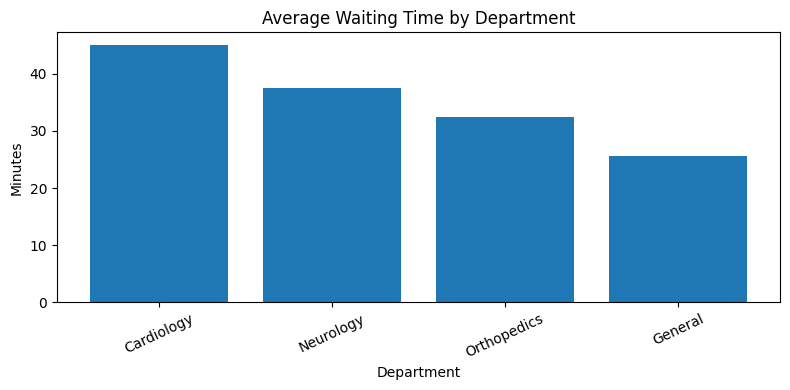

In [14]:
# Visualize waiting time
plt.figure(figsize=(8, 4))
plt.bar(dept_wait["department"], dept_wait["waiting_minutes"])
plt.title("Average Waiting Time by Department")
plt.xlabel("Department")
plt.ylabel("Minutes")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


## 8. Patient Risk Analytics

The following analysis counts patients by the demonstration risk category.


In [15]:
risk_summary = data["risk_level"].value_counts().reindex(["Low", "Medium", "High"]).fillna(0)
risk_summary


risk_level
Low       5
Medium    2
High      3
Name: count, dtype: int64

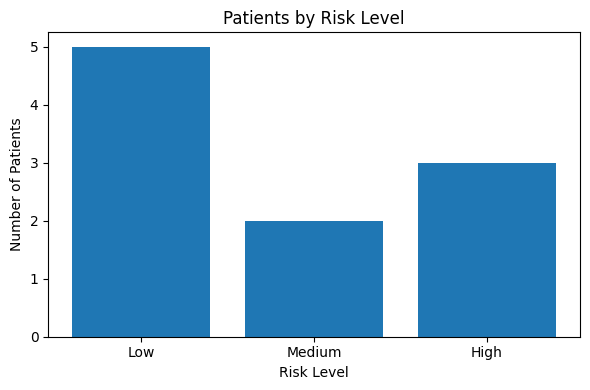

In [16]:
plt.figure(figsize=(6, 4))
plt.bar(risk_summary.index.astype(str), risk_summary.values)
plt.title("Patients by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()


## 9. High-Risk Patient View

This view provides a compact list that hospital staff could use for additional review. It should be treated as an analytics flag only and must not replace professional clinical judgment.


In [17]:
high_risk = data.loc[
    data["risk_level"] == "High",
    ["patient_id", "age", "department", "risk_score", "oxygen_sat",
     "heart_rate", "glucose", "symptom_score"]
].sort_values("risk_score", ascending=False)

high_risk


,patient_id,age,department,risk_score,oxygen_sat,heart_rate,glucose,symptom_score
3,1004,72,Cardiology,7,91,105,190,8
6,1007,81,Cardiology,7,89,112,210,9
8,1009,63,Neurology,6,93,101,172,7


## 10. Data Pipeline Monitoring

A production pipeline should monitor data freshness, record counts, null values and failed records. The following simple checks demonstrate the idea.


In [18]:
# Basic pipeline monitoring metrics
monitor = pd.DataFrame({
    "metric": [
        "source patient rows",
        "integrated rows",
        "null values",
        "duplicate rows",
        "high-risk records"
    ],
    "value": [
        len(patients),
        len(data),
        int(data.isna().sum().sum()),
        int(data.duplicated().sum()),
        int((data["risk_level"] == "High").sum())
    ]
})

monitor


,metric,value
0,source patient rows,10
1,integrated rows,10
2,null values,0
3,duplicate rows,0
4,high-risk records,3


## 11. Export Final Dataset

The analytics-ready dataset is exported as CSV so it can be reused by dashboards or other tools.


In [19]:
output_file = "hospital_patient_analytics.csv"
data.to_csv(output_file, index=False)

print("Exported:", output_file)


Exported: hospital_patient_analytics.csv


## 12. Final Architecture

```text
Patient Registration ─┐
Appointments ─────────┤
Lab Reports ──────────┤
Wearable Devices ─────┼──> Ingestion ──> Data Quality ──> Transformation
Consultation Notes ───┘                                      │
                                                             ▼
                                                     Integrated Dataset
                                                             │
                                                             ▼
                                                    Analytics Storage
                                                             │
                                          ┌──────────────────┼──────────────────┐
                                          ▼                  ▼                  ▼
                                   Waiting Time KPIs    Risk Flags       Department KPIs
```

## 13. Conclusion

This notebook demonstrates an end-to-end hospital data engineering pipeline:

- Multiple healthcare source systems are simulated.
- Data quality checks are performed.
- Data is integrated using `patient_id`.
- Features are transformed for analytics.
- Processed data is stored in SQLite.
- Waiting-time and patient-risk analytics are generated.
- A CSV output is created for downstream use.
- Pipeline monitoring metrics are included.

**Student:** Chetan Kalagarla  
**Student ID:** 2300033450
